## Imports & load data:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load data
train_df = pd.read_csv('../data/processed/train.csv')
test_df  = pd.read_csv('../data/processed/test.csv')

# Load arrays
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy').ravel()
y_test  = np.load('../data/processed/y_test.npy').ravel()

# Load scalers & feature cols
with open('../models/scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open('../models/scaler_Y.pkl', 'rb') as f:
    scaler_Y = pickle.load(f)
with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("All data loaded successfully!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"Features: {len(feature_cols)}")

All data loaded successfully!
X_train: (14981, 43) | X_test: (3746, 43)
y_train: (14981,) | y_test: (3746,)
Features: 43


## Helper function for evaluation:

In [3]:
def evaluate_model(name, y_true_scaled, y_pred_scaled, scaler_Y):
    """Inverse transform and compute RMSE & MAE in original units (Wh)"""
    y_true = scaler_Y.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    y_pred = scaler_Y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name} — Evaluation Results")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.2f} Wh")
    print(f"  MAE  : {mae:.2f} Wh")

    return rmse, mae, y_true, y_pred



 ## Baseline: Ridge Regression:

In [5]:
print("Training Ridge Regression (baseline)...")

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

ridge_rmse, ridge_mae, y_true_orig, y_pred_ridge_orig = evaluate_model(
    "Ridge Regression", y_test, y_pred_ridge, scaler_Y
)

# Save model
with open('../models/ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge, f)

print("\nRidge model saved to models/ridge_model.pkl ")

Training Ridge Regression (baseline)...

  Ridge Regression — Evaluation Results
  RMSE : 21.35 Wh
  MAE  : 14.43 Wh

Ridge model saved to models/ridge_model.pkl 


## Random Forest with GridSearchCV

In [6]:
print("Tuning Random Forest with GridSearchCV...")
print("(This may take 3-5 minutes — please wait)\n")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'neg_root_mean_squared_error',
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV RMSE: {-grid_search.best_score_:.4f}")

Tuning Random Forest with GridSearchCV...
(This may take 3-5 minutes — please wait)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters found:
  max_depth: 10
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 100

Best CV RMSE: 0.1525


## Evaluate best Random Forest:

In [8]:
# Get best model
rf_model = grid_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)

rf_rmse, rf_mae, y_true_orig, y_pred_rf_orig = evaluate_model(
    "Random Forest", y_test, y_pred_rf, scaler_Y
)

# Save model
with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("\nRandom Forest model saved to models/rf_model.pkl ")


  Random Forest — Evaluation Results
  RMSE : 24.16 Wh
  MAE  : 18.75 Wh

Random Forest model saved to models/rf_model.pkl 


 ## Actual vs Predicted plot:

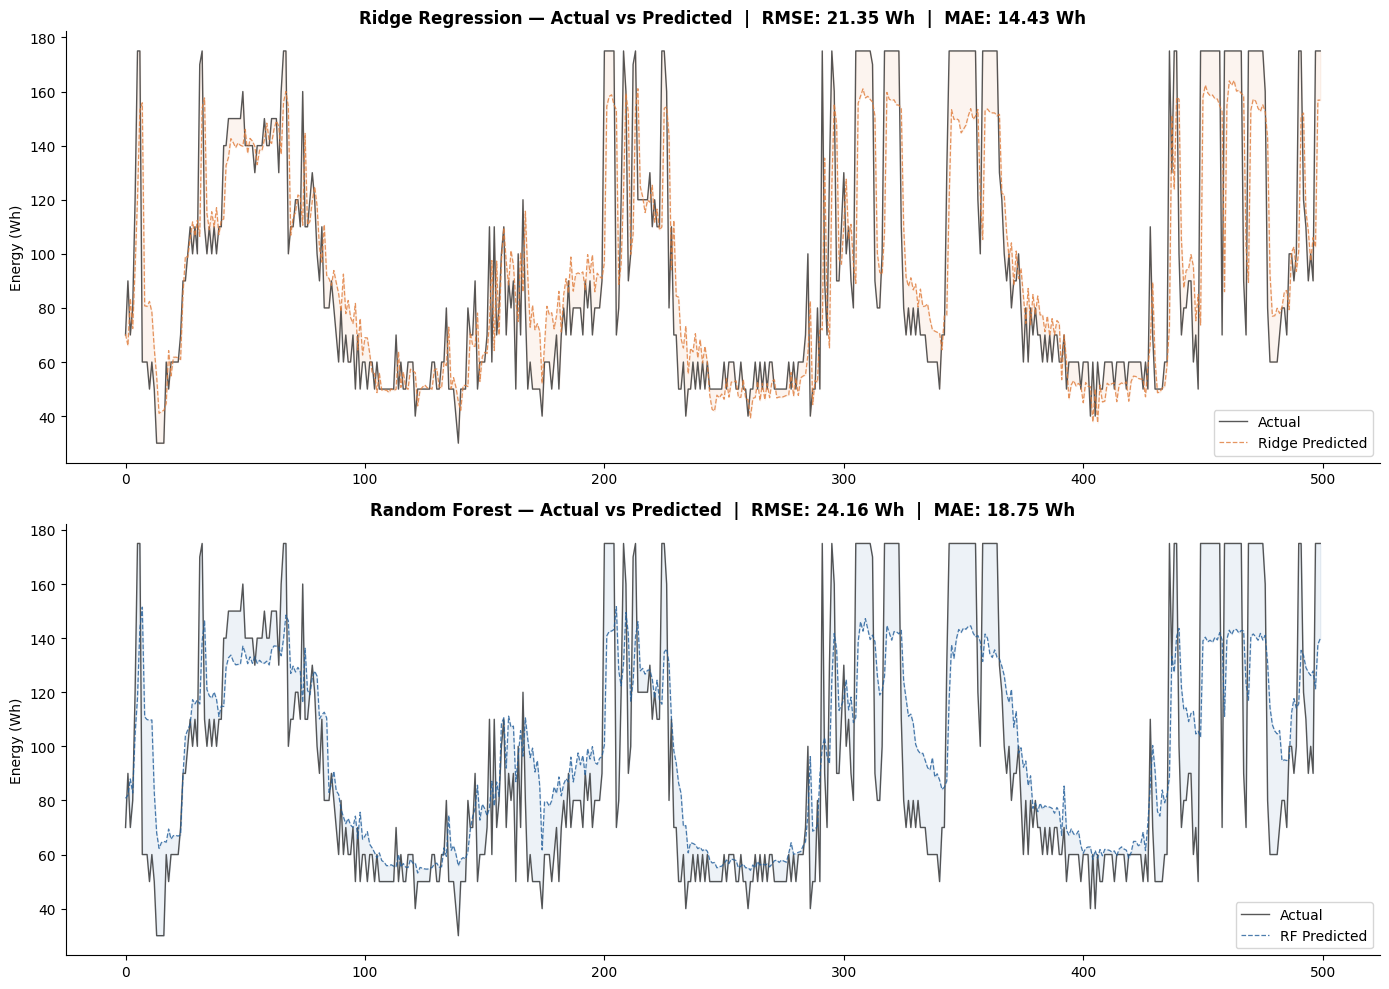

In [9]:
# Use last 500 test points for clarity
n = 500
x_axis = range(n)

y_true_plot  = y_true_orig[-n:]
y_ridge_plot = y_pred_ridge_orig[-n:]
y_rf_plot    = y_pred_rf_orig[-n:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Ridge
axes[0].plot(x_axis, y_true_plot,  color='#2E2E2E', linewidth=1,   label='Actual',          alpha=0.8)
axes[0].plot(x_axis, y_ridge_plot, color='#E07B39', linewidth=0.9, label='Ridge Predicted',  alpha=0.8, linestyle='--')
axes[0].fill_between(x_axis,
                     y_true_plot, y_ridge_plot,
                     alpha=0.08, color='#E07B39')
axes[0].set_title(f'Ridge Regression — Actual vs Predicted  |  RMSE: {ridge_rmse:.2f} Wh  |  MAE: {ridge_mae:.2f} Wh',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Energy (Wh)')
axes[0].legend()

# Random Forest
axes[1].plot(x_axis, y_true_plot, color='#2E2E2E', linewidth=1,   label='Actual',             alpha=0.8)
axes[1].plot(x_axis, y_rf_plot,   color='#1F5C99', linewidth=0.9, label='RF Predicted',       alpha=0.8, linestyle='--')
axes[1].fill_between(x_axis,
                     y_true_plot, y_rf_plot,
                     alpha=0.08, color='#1F5C99')
axes[1].set_title(f'Random Forest — Actual vs Predicted  |  RMSE: {rf_rmse:.2f} Wh  |  MAE: {rf_mae:.2f} Wh',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Energy (Wh)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/15_actual_vs_predicted_rf.png', bbox_inches='tight')
plt.show()

## Feature importance plot

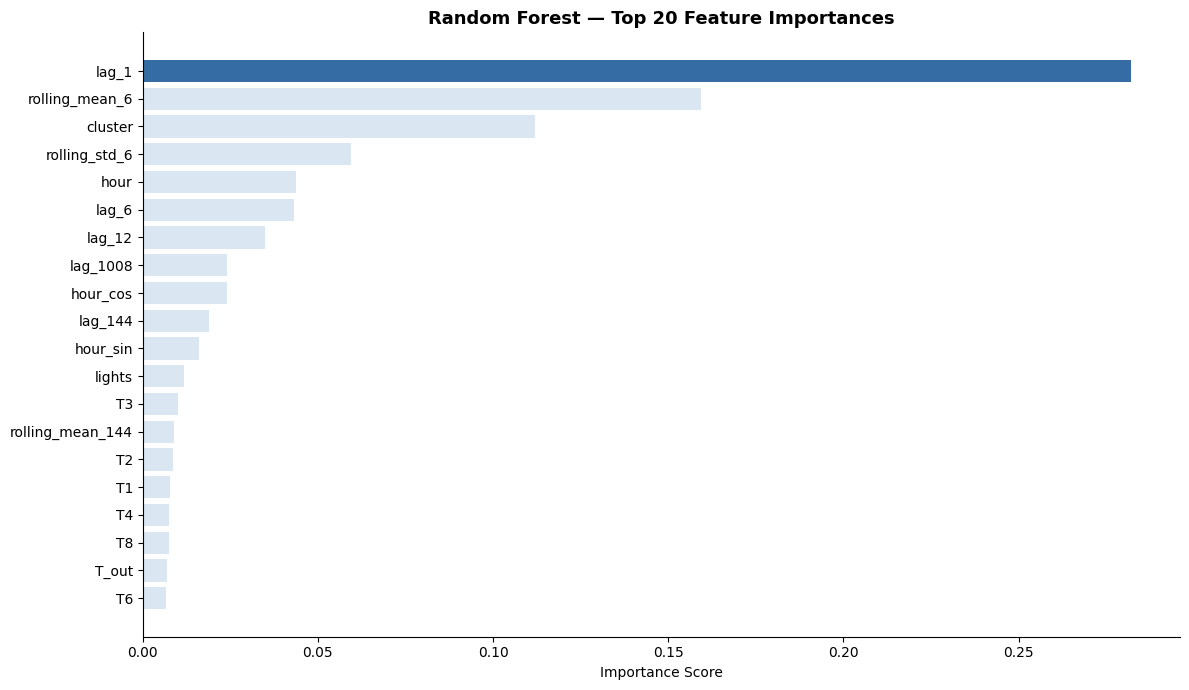

Top 10 most important features:
   1. lag_1                     0.2820
   2. rolling_mean_6            0.1593
   3. cluster                   0.1121
   4. rolling_std_6             0.0593
   5. hour                      0.0439
   6. lag_6                     0.0432
   7. lag_12                    0.0348
   8. lag_1008                  0.0240
   9. hour_cos                  0.0239
  10. lag_144                   0.0191


In [10]:
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1][:20]  # Top 20

top_features    = [feature_cols[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(12, 7))
colors = ['#1F5C99' if i == 0 else '#D6E4F0' for i in range(len(top_features))]
plt.barh(top_features[::-1], top_importances[::-1], color=colors[::-1], alpha=0.9)
plt.title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/16_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
for i, (feat, imp) in enumerate(zip(top_features[:10], top_importances[:10])):
    print(f"  {i+1:2}. {feat:<25} {imp:.4f}")

 ## Residual analysis

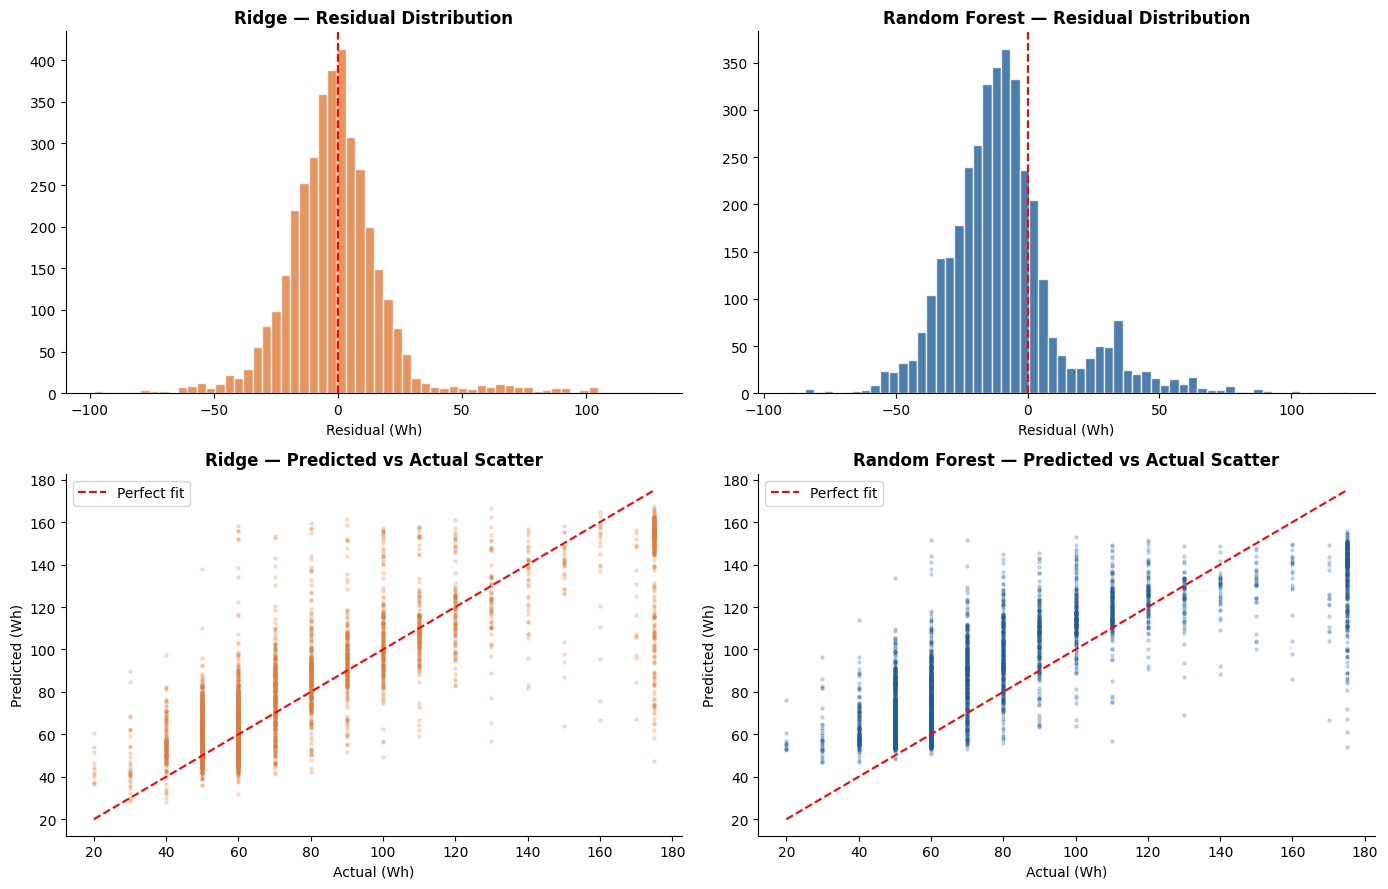

In [11]:
residuals_ridge = y_true_orig - y_pred_ridge_orig
residuals_rf    = y_true_orig - y_pred_rf_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Ridge residuals distribution
axes[0, 0].hist(residuals_ridge, bins=60, color='#E07B39', alpha=0.8, edgecolor='white')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Ridge — Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Residual (Wh)')

# RF residuals distribution
axes[0, 1].hist(residuals_rf, bins=60, color='#1F5C99', alpha=0.8, edgecolor='white')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Random Forest — Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual (Wh)')

# Ridge scatter: predicted vs actual
axes[1, 0].scatter(y_true_orig, y_pred_ridge_orig, alpha=0.2, s=5, color='#E07B39')
axes[1, 0].plot([y_true_orig.min(), y_true_orig.max()],
                [y_true_orig.min(), y_true_orig.max()],
                'r--', linewidth=1.5, label='Perfect fit')
axes[1, 0].set_title('Ridge — Predicted vs Actual Scatter', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual (Wh)')
axes[1, 0].set_ylabel('Predicted (Wh)')
axes[1, 0].legend()

# RF scatter: predicted vs actual
axes[1, 1].scatter(y_true_orig, y_pred_rf_orig, alpha=0.2, s=5, color='#1F5C99')
axes[1, 1].plot([y_true_orig.min(), y_true_orig.max()],
                [y_true_orig.min(), y_true_orig.max()],
                'r--', linewidth=1.5, label='Perfect fit')
axes[1, 1].set_title('Random Forest — Predicted vs Actual Scatter', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Actual (Wh)')
axes[1, 1].set_ylabel('Predicted (Wh)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/17_residual_analysis.png', bbox_inches='tight')
plt.show()

 ## Save results:

In [12]:
import json

# Save metrics to results file
results = {
    'Ridge Regression': {'RMSE': round(ridge_rmse, 2), 'MAE': round(ridge_mae, 2)},
    'Random Forest':    {'RMSE': round(rf_rmse, 2),    'MAE': round(rf_mae, 2)},
}

with open('../outputs/results.json', 'w') as f:
    json.dump(results, f, indent=4)

# Print comparison so far
print("="*45)
print("  Model Comparison (so far)")
print("="*45)
print(f"  {'Model':<22} {'RMSE':>8} {'MAE':>8}")
print(f"  {'-'*40}")
print(f"  {'Ridge Regression':<22} {ridge_rmse:>8.2f} {ridge_mae:>8.2f}")
print(f"  {'Random Forest':<22} {rf_rmse:>8.2f} {rf_mae:>8.2f}")
print(f"  {'LSTM':<22} {'TBD':>8} {'TBD':>8}")
print(f"\nRF improvement over Ridge:")
print(f"  RMSE reduced by: {ridge_rmse - rf_rmse:.2f} Wh ({(ridge_rmse-rf_rmse)/ridge_rmse*100:.1f}%)")
print(f"  MAE  reduced by: {ridge_mae  - rf_mae:.2f}  Wh ({(ridge_mae-rf_mae)/ridge_mae*100:.1f}%)")

print("\nSaved:")
print("  models/ridge_model.pkl")
print("  models/rf_model.pkl")
print("  outputs/results.json")
print("\nPhase 5 complete! Move on to 06_lstm.ipynb ")

  Model Comparison (so far)
  Model                      RMSE      MAE
  ----------------------------------------
  Ridge Regression          21.35    14.43
  Random Forest             24.16    18.75
  LSTM                        TBD      TBD

RF improvement over Ridge:
  RMSE reduced by: -2.81 Wh (-13.2%)
  MAE  reduced by: -4.32  Wh (-30.0%)

Saved:
  models/ridge_model.pkl
  models/rf_model.pkl
  outputs/results.json

Phase 5 complete! Move on to 06_lstm.ipynb 
